### Alunos
NATHAN CARDOSO LINHARES  2026010155

PEDRO VINICIUS DE ANDRADE QUEIROZ 2026010152     

### Questão 1

In [22]:
import pandas as pd
import os
import kagglehub

# Download do dataset
path = kagglehub.dataset_download("hassan06/nslkdd")

# Caminho do arquivo de treino
train_path = os.path.join(path, "KDDTrain+.txt")
test_path = os.path.join(path, "KDDTest+.txt")

# Nome das colunas
col_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "attack_type", "difficulty_level"
]

# Carrega o dataset
train_df = pd.read_csv(train_path, names=col_names)
test_df = pd.read_csv(test_path, names=col_names)

# Exibe o dataset
display(train_df)
display(test_df)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,difficulty_level
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.00,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71,mscan,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,0,tcp,smtp,SF,794,333,0,0,0,0,...,0.72,0.06,0.01,0.01,0.01,0.0,0.00,0.00,normal,21
22540,0,tcp,http,SF,317,938,0,0,0,0,...,1.00,0.00,0.01,0.01,0.01,0.0,0.00,0.00,normal,21
22541,0,tcp,http,SF,54540,8314,0,0,0,2,...,1.00,0.00,0.00,0.00,0.00,0.0,0.07,0.07,back,15
22542,0,udp,domain_u,SF,42,42,0,0,0,0,...,0.99,0.01,0.00,0.00,0.00,0.0,0.00,0.00,normal,21


In [23]:
import numpy as np

# Remover coluna difficulty_level
train_df.drop(columns=["difficulty_level"], inplace=True)
test_df.drop(columns=["difficulty_level"], inplace=True)

# Binarizando rotulo
categorical_cols = ["protocol_type", "service", "flag"]
numeric_cols = [c for c in train_df.columns if c not in categorical_cols + ["attack_type"]]

# One-hot encoding
n_train = len(train_df)
combined = pd.concat([train_df, test_df], axis=0)
combined = pd.get_dummies(combined, columns=categorical_cols, dtype=float)
train_df = combined.iloc[:n_train].reset_index(drop=True)
test_df  = combined.iloc[n_train:].reset_index(drop=True)

# Binarizar o rótulo, normal para 0 e qualquer ataque para 1
train_df["attack_type"] = train_df["attack_type"].apply(lambda x: 0 if x == "normal" else 1)
test_df["attack_type"]  = test_df["attack_type"].apply(lambda x: 0 if x == "normal" else 1)

# Separar X e y
X_train = train_df.drop(columns=["attack_type"]).copy()
y_train = train_df["attack_type"]
X_test  = test_df.drop(columns=["attack_type"]).copy()
y_test  = test_df["attack_type"]

# Normalização Z-score nos atributos numéricos
mean = X_train[numeric_cols].mean()
std  = X_train[numeric_cols].std()
std[std == 0] = 1

X_train[numeric_cols] = (X_train[numeric_cols] - mean) / std
X_test[numeric_cols]  = (X_test[numeric_cols]  - mean) / std

X_train = X_train.values
X_test  = X_test.values

print("Shape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test :", y_test.shape)

Shape X_train: (125973, 122)
Shape X_test : (22544, 122)
Shape y_train: (125973,)
Shape y_test : (22544,)


### Questão 2

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# Dividindo treino e validação (80/20)
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    shuffle=False
)

# Conversão para tensores
X_train_tensor = torch.tensor(X_train_final, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_final.values, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,   y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor,  y_test_tensor)

batch_size = 256

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# Implementando o modelo MLP
class MLP(nn.Module):

    def __init__(self, input_size):

        super(MLP, self).__init__()

        self.network = nn.Sequential(
            
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):

        return self.network(x)

input_size = X_train_tensor.shape[1]
model = MLP(input_size)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# Verificando o modelo
print(model)

MLP(
  (network): Sequential(
    (0): Linear(in_features=122, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


### Questão 3

Época [1/50] | Perda Treino: 0.1053 | Perda Val: 0.0288
Época [2/50] | Perda Treino: 0.0305 | Perda Val: 0.0212
Época [3/50] | Perda Treino: 0.0238 | Perda Val: 0.0184
Época [4/50] | Perda Treino: 0.0219 | Perda Val: 0.0181
Época [5/50] | Perda Treino: 0.0201 | Perda Val: 0.0163
Época [6/50] | Perda Treino: 0.0192 | Perda Val: 0.0159
Época [7/50] | Perda Treino: 0.0179 | Perda Val: 0.0148
Época [8/50] | Perda Treino: 0.0169 | Perda Val: 0.0143
Época [9/50] | Perda Treino: 0.0160 | Perda Val: 0.0134
Época [10/50] | Perda Treino: 0.0163 | Perda Val: 0.0138
Época [11/50] | Perda Treino: 0.0147 | Perda Val: 0.0129
Época [12/50] | Perda Treino: 0.0142 | Perda Val: 0.0133
Época [13/50] | Perda Treino: 0.0145 | Perda Val: 0.0137
Época [14/50] | Perda Treino: 0.0149 | Perda Val: 0.0133
Época [15/50] | Perda Treino: 0.0133 | Perda Val: 0.0130
Época [16/50] | Perda Treino: 0.0129 | Perda Val: 0.0122
Época [17/50] | Perda Treino: 0.0128 | Perda Val: 0.0123
Época [18/50] | Perda Treino: 0.0129 | P

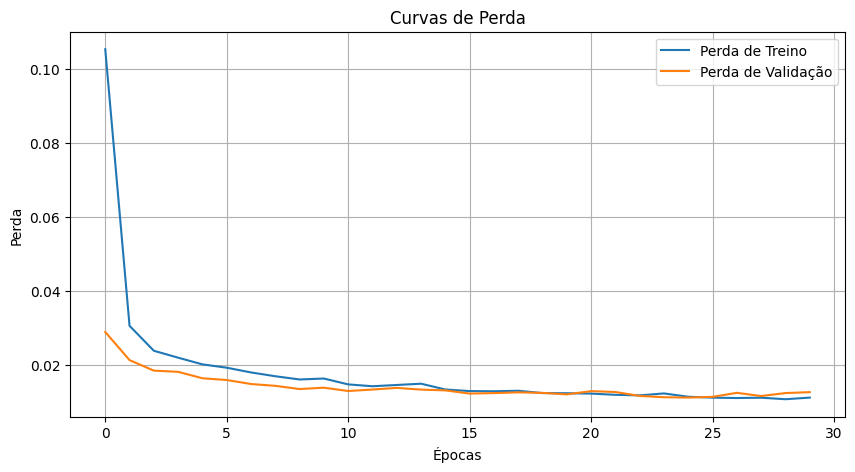

In [25]:
import matplotlib.pyplot as plt

# Parâmetros de treinamento
num_epochs = 50
train_losses = []
val_losses   = []
best_val_loss = np.inf
patience = 5
counter  = 0

# Treinamento
for epoch in range(num_epochs):

    # Modo de treinamento
    model.train()
    running_train_loss = 0.0
    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)
    train_losses.append(train_loss)
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)
    val_losses.append(val_loss)

    # Resultados
    print(
        f"Época [{epoch+1}/{num_epochs}] "
        f"| Perda Treino: {train_loss:.4f} "
        f"| Perda Val: {val_loss:.4f}"
    )

    # Parada antecipada
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}

    else:
        counter += 1

    # Critério de parada
    if counter >= patience:
        print("\nParada antecipada ativada!")
        break

# Plotagem das curvas de perda
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Perda de Treino")
plt.plot(val_losses,   label="Perda de Validação")

plt.xlabel("Épocas")
plt.ylabel("Perda")
plt.title("Curvas de Perda")

plt.legend()
plt.grid(True)
plt.show()

### Questão 4

In [26]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

model.load_state_dict(best_model_state)
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        probs = torch.sigmoid(model(X_batch))
        preds = (probs >= 0.5).float()
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()

print("Matriz de Confusao:")
print(confusion_matrix(all_labels, all_preds))

print(f"Acuracia : {accuracy_score(all_labels, all_preds):.4f}")
print(f"Precisao : {precision_score(all_labels, all_preds):.4f}")
print(f"Recall   : {recall_score(all_labels, all_preds):.4f}")
print(f"F1-Score : {f1_score(all_labels, all_preds):.4f}")

Matriz de Confusao:
[[9028  683]
 [4227 8606]]
Acuracia : 0.7822
Precisao : 0.9265
Recall   : 0.6706
F1-Score : 0.7780


O erro mais crítico para esse tipo de sistemas é o falso negativo, pois ele permite que um ataque real seja classificado como normal e passe despercebido. Já o falso positivo apenas gera alertas errados para conexões legítimas. 
Para reduzir faltos negativos, o limiar de decisão costuma ser deminuído, deixando o sistema mais sensível e melhorando a detecção de ataques.